# Seleccion de Variables con Step Forward


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal
* Regresion lineal regularizada
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando step forwarding para regresion lineal. 

In [64]:
library(MASS)
library(leaps)
library(glmnet)
library(pracma)
library(raster)
library(ggplot2)
source("Utils.R")

In [3]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

In [4]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y

hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

### Mediante KFold con K=40 elegimos la mejor cantidad de variables (que no sobreajuste)

In [26]:
setSeed()

n = nrow(TRAIN_X)
k = 40

nvmax=n-n/k
resultados <- matrix(0, nrow=k, ncol = nvmax-1)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax-1)
    
    for(j in 1:(nvmax-1)){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 7.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 10 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 12.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 15 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“146  linear dependencies found”
El progreso es del 17.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = 

In [68]:
result <- as.data.frame(resultados)
colnames(result) <- seq(1, 155)

In [92]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(1,155)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

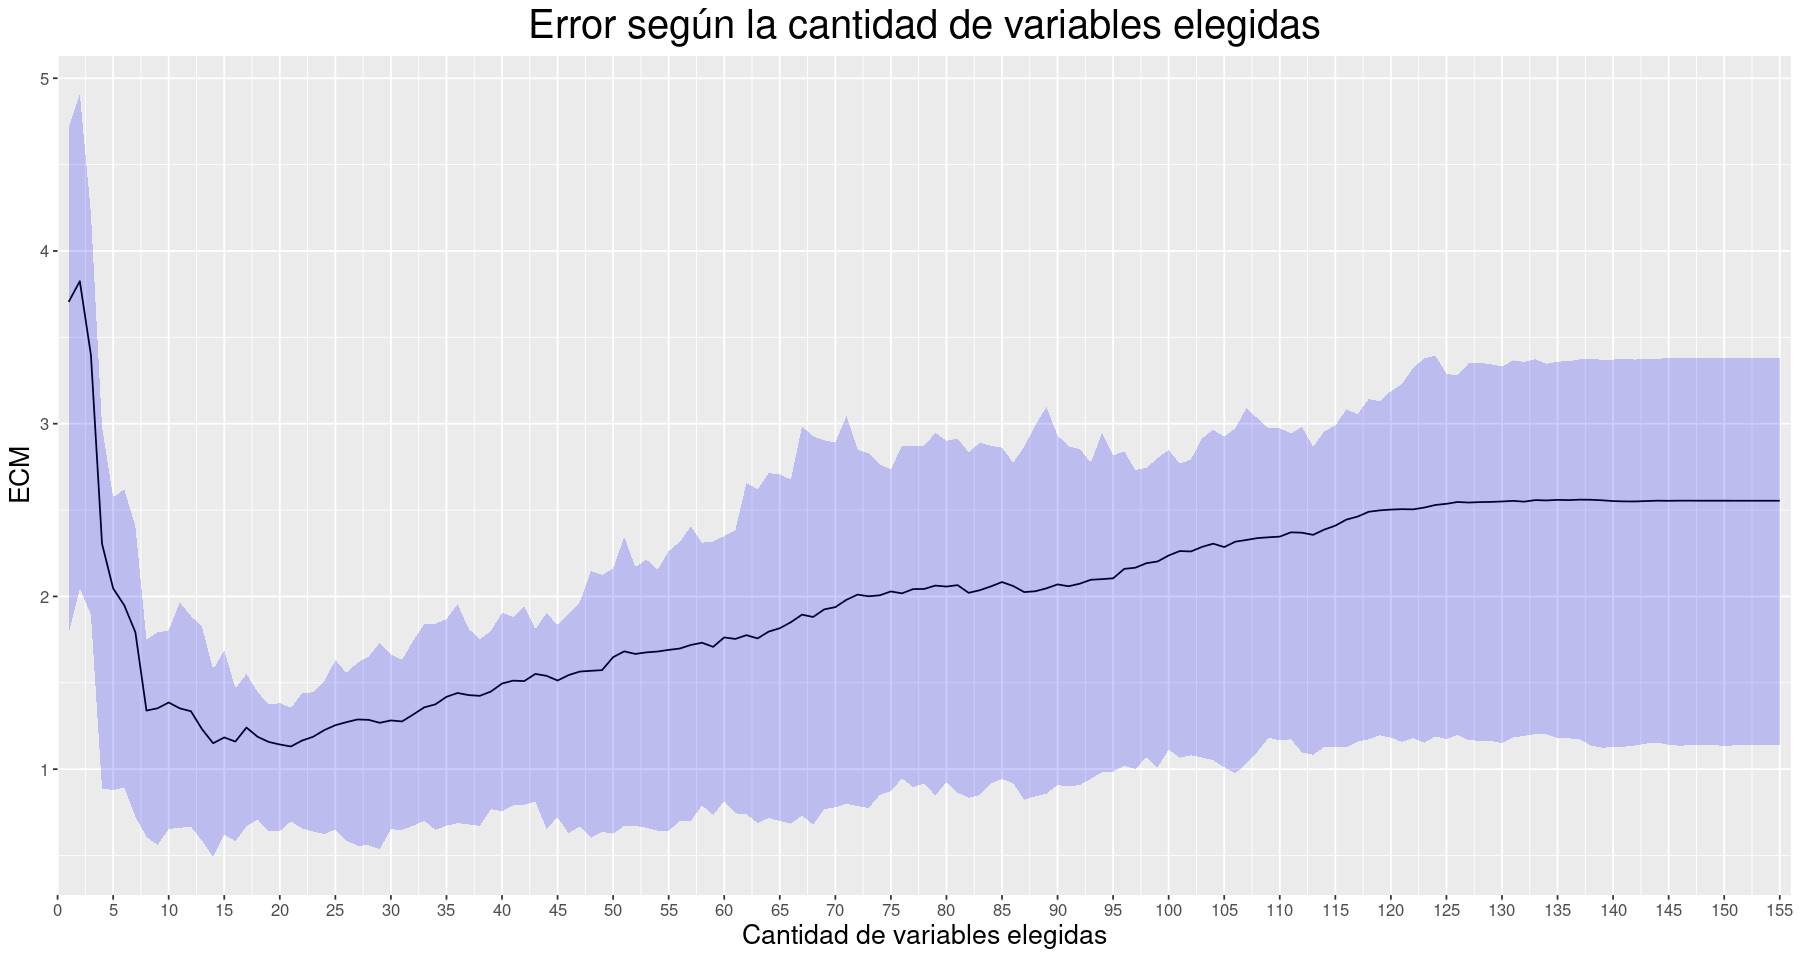

In [101]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(0, 155, by=5), expand = c(0, 1))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Vemos en este gráfico que entre 10 y 30 el error se comporta de forma similar, para luego empezar a overfittear, por lo que haremos ahora un gráfico más detallado sobre esta zona.

In [102]:
setSeed()

n = nrow(TRAIN_X)
k = n

nvmax=30
nvmin=10
resultados <- matrix(0, nrow=k, ncol = nvmax)

X = TRAIN_X

indices = obtener_indices_kfold(n, k)
a=1
for(i in indices){
    DF_train = X[-i,]
    DF_train$Y = TRAIN_Y[-i]

    DF_test = X[i,]
    DF_test$Y = TRAIN_Y[i]
    
    forw <- regsubsets(Y~., data=DF_train, method = "forward", nvmax=nvmax)
    
    for(j in nvmin:nvmax){
        Y_pred = predict(forw, DF_test, id=j)
        resultados[[a, j]] = mean( (DF_test$Y - Y_pred)^2 )
    }
    a=a+1
    message(progreso(a, 1:k))
}

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 1.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 2.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 3.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 4.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest 

El progreso es del 33.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 33.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 34.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 35.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 36.9 %

Warning message in le

El progreso es del 65.6 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.2 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 66.9 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 67.5 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 68.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 69.4 %

Warning message in 

El progreso es del 98.1 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 98.8 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 99.4 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
El progreso es del 100 %

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“143  linear dependencies found”
???



In [115]:
result <- as.data.frame(resultados[, 10:30])
colnames(result) <- seq(10, 30)

In [118]:
a <- as.data.frame(t(apply(result, 2, summary)))
a$ind = seq(10, 30)
colnames(a) <- c("min", "q1", "median", "mean", "q3", "max", "ind")

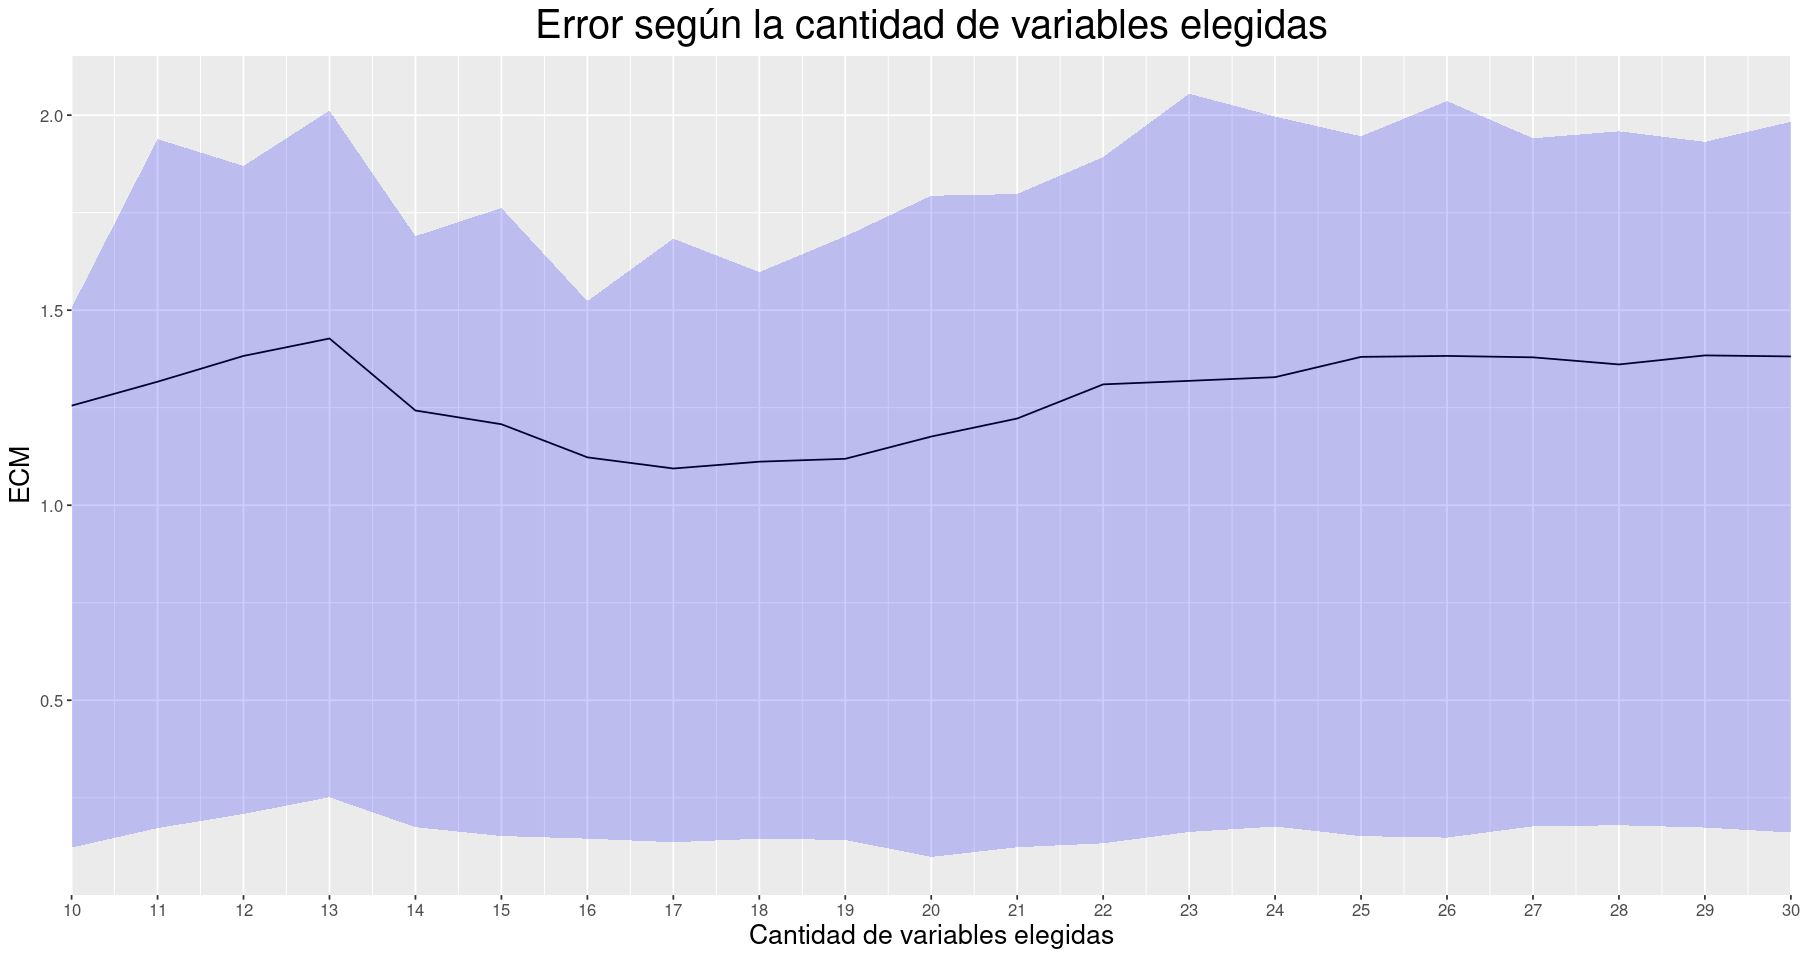

In [137]:
options(repr.plot.width=15, repr.plot.height=8)
theme_update(plot.title = element_text(hjust = 0.5, size = 24),
                          axis.text=element_text(size=10),
                          axis.title=element_text(size=16))

ggplot(a, aes(x=ind, y=mean)) +
    geom_line() +
    geom_ribbon(aes(ymin=q1, ymax=q3), fill="blue", alpha=0.2) +
    scale_x_continuous(breaks = seq(10, 30, by=1), expand = c(0, 0))+
    ggtitle("Error según la cantidad de variables elegidas") + 
    xlab("Cantidad de variables elegidas") + ylab("ECM")

Nos quedamos entonces con 17, pues es el valor con menor ECM por LOOCV

## Las variables elegidas

In [122]:
n = nrow(TRAIN_X)

forw <- regsubsets(Y~., data = TRAIN_DF, method = "forward", nvmax = 17

Warning message in leaps.setup(x, y, wt = wt, nbest = nbest, nvmax = nvmax, force.in = force.in, :
“142  linear dependencies found”


In [200]:
vs <- names(which(summary(forw)$which[17, ])[2:18])
vs

[1] "V1"   "V6"   "V8"   "V36"  "V59"  "V70"  "V74"  "V88"  "V112" "V126"
[11] "V133" "V142" "V143" "V193" "V235" "V242" "V243"

In [290]:
SELECTED_TRAIN_X = TRAIN_DF[, vs]
SELECTED_TRAIN_DF = SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y = TRAIN_Y

SELECTED_HOLDOUT_X = HOLDOUT_DF[, vs]
SELECTED_HOLDOUT_DF = SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y = HOLDOUT_Y

# Modelo 1: regresion Lineal

In [203]:
# No escalamos los datos porque no hay regularizacion.
modelo1 <- lm(Y~., data = SELECTED_TRAIN_DF)

Y_pred = predict(modelo1, SELECTED_TRAIN_X)
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.539609005425229"


In [204]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.690052227476859"


In [205]:
p = ncol(SELECTED_TRAIN_X)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.956066368347469"


# Modelo 2: regresion Lineal Regularizada

In [216]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 10
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 30)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 4.8 %

El progreso es del 9.5 %

El progreso es del 14.3 %

El progreso es del 19 %

El progreso es del 23.8 %

El progreso es del 28.6 %

El progreso es del 33.3 %

El progreso es del 38.1 %

El progreso es del 42.9 %

El progreso es del 47.6 %

El progreso es del 52.4 %

El progreso es del 57.1 %

El progreso es del 61.9 %

El progreso es del 66.7 %

El progreso es del 71.4 %

El progreso es del 76.2 %

El progreso es del 81 %

El progreso es del 85.7 %

El progreso es del 90.5 %

El progreso es del 95.2 %

El progreso es del 100 %



In [217]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
,<dbl>,<dbl>,<int>,<dbl>
38,0,0.01172102,2,0.6707074


##### Calculo del error por LOOCV

In [218]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.686260179392936"


In [219]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
modelo2 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo2$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.95630779709314"


In [221]:
p

[1] 17

# Modelo 3: árbol de regresión

In [222]:
library(rpart)
library(rpart.plot)

In [225]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)
maxdepths <- c(4, 5, 6, 7, 8)
cps <- c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)
for (minsplit in minsplits) {
    for (maxdepth in maxdepths) {
        for (cp in cps) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 16.7 %

El progreso es del 33.3 %

El progreso es del 50 %

El progreso es del 66.7 %

El progreso es del 83.3 %

El progreso es del 100 %



In [226]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,Minsplit,Maxdepth,CP,Error
,<dbl>,<dbl>,<dbl>,<dbl>
43,5,6,5e-04,1.406194


In [227]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo3 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

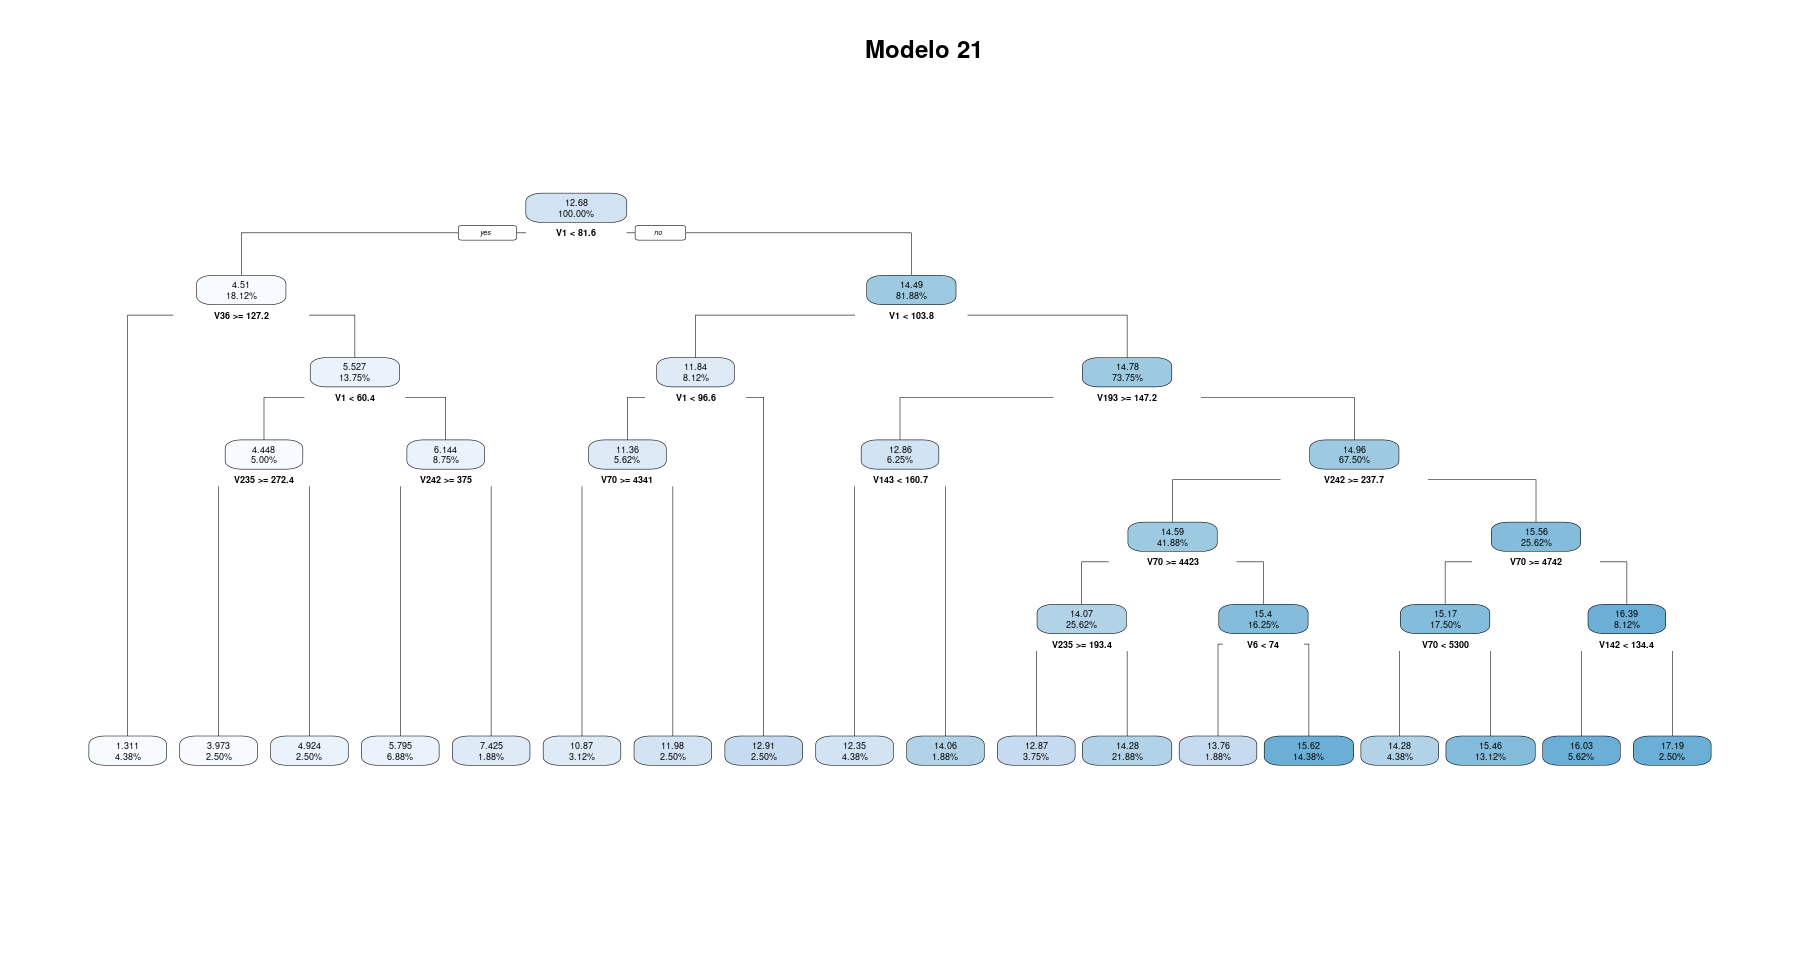

In [228]:
rpart.plot(modelo3, digits=4)
title("Modelo 21")

In [229]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.47908489124642"


In [258]:
a <- summary(modelo3)

Call:
rpart(formula = Y ~ ., data = SELECTED_TRAIN_DF, control = parametros)
  n= 160 

             CP nsplit  rel error     xerror       xstd
1  0.8457815140      0 1.00000000 1.01476076 0.13685629
2  0.0361883367      1 0.15421849 0.19127944 0.02838930
3  0.0337894459      2 0.11803015 0.16951896 0.02339266
4  0.0143301259      3 0.08424070 0.11221767 0.01699241
5  0.0092920923      4 0.06991058 0.10582307 0.01715122
6  0.0052399391      6 0.05132639 0.09464670 0.01712259
7  0.0047347947      7 0.04608645 0.08869001 0.01533476
8  0.0036262996      8 0.04135166 0.08875573 0.01530588
9  0.0032610230      9 0.03772536 0.09270611 0.01545485
10 0.0026137963     10 0.03446434 0.09530000 0.01545044
11 0.0023878169     11 0.03185054 0.09271419 0.01504682
12 0.0022406086     12 0.02946272 0.08681253 0.01187968
13 0.0022076323     13 0.02722211 0.08558168 0.01186425
14 0.0013318896     14 0.02501448 0.08528534 0.01210622
15 0.0009848176     15 0.02368259 0.08598326 0.01224254
16 0.0006466486 

[1] V1     V36    <leaf> V1     V235   <leaf> <leaf> V242   <leaf> <leaf>
[11] V1     V1     V70    <leaf> <leaf> <leaf> V193   V143   <leaf> <leaf>
[21] V242   V70    V235   <leaf> <leaf> V6     <leaf> <leaf> V70    V70   
[31] <leaf> <leaf> V142   <leaf> <leaf>
Levels: <leaf> V1 V142 V143 V193 V235 V242 V36 V6 V70

In [262]:
p = length(unique(a$frame$var))-1
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.910820027648752"


# Modelo 4: KNN

In [263]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

In [277]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

El progreso es del 10 %

El progreso es del 20 %

El progreso es del 30 %

El progreso es del 40 %

El progreso es del 50 %

El progreso es del 60 %

El progreso es del 70 %

El progreso es del 80 %

El progreso es del 90 %

El progreso es del 100 %



In [278]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Escalador,Error
,<int>,<dbl>,<dbl>,<int>,<dbl>
14,2,2,1,2,0.7126266


In [284]:
escalador = MMScaler()
X_train_scaled = as.matrix(escalador$fit_transform(X))
Y_train = TRAIN_Y
modelo4 = knnr(n_neighbors=as.integer(2),
                p=1,
                weights="distance")
modelo4 = modelo4$fit(X_train_scaled, Y_train)

In [285]:
modelo4

KNeighborsRegressor(n_neighbors=2, p=1.0, weights='distance')

Calculo del error

In [266]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.703075796803655"


In [267]:
p = 17
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9552372

# Modelo 5: regresión no paramétrica

In [268]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [269]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

El progreso es del 3.3 %

El progreso es del 6.7 %

El progreso es del 10 %

El progreso es del 13.3 %

El progreso es del 16.7 %

El progreso es del 20 %

El progreso es del 23.3 %

El progreso es del 26.7 %

El progreso es del 30 %

El progreso es del 33.3 %

El progreso es del 36.7 %

El progreso es del 40 %

El progreso es del 43.3 %

El progreso es del 46.7 %

El progreso es del 50 %

El progreso es del 53.3 %

El progreso es del 56.7 %

El progreso es del 60 %

El progreso es del 63.3 %

El progreso es del 66.7 %

El progreso es del 70 %

El progreso es del 73.3 %

El progreso es del 76.7 %

El progreso es del 80 %

El progreso es del 83.3 %

El progreso es del 86.7 %

El progreso es del 90 %

El progreso es del 93.3 %

El progreso es del 96.7 %

El progreso es del 100 %



In [270]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,K,Error
,<dbl>,<int>,<dbl>
10,1.127586,2,0.8583506


In [271]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    
    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.913815409537324"


In [273]:
p = 17
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.94182

# Predicciones sobre HoldOut

In [310]:
# Funcion de error
err <- function(y, ypred){
    mean((y-ypred)^2)
}

In [299]:
# Modelo 1
modelo1 <- lm(Y~., data = SELECTED_TRAIN_DF)
Y_pred <- predict(modelo1, newdata=SELECTED_HOLDOUT_DF)
err(HOLDOUT_Y, Y_pred)

[1] 0.8694598

In [309]:
# Modelo 2
escalador=MMScaler()
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_test_scaled <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
modelo2 <- glmnet(X_train_scaled, TRAIN_Y, lambda=0.01172102, alpha=0)
Y_pred <- as.double(predict(modelo2, X_test_scaled))
err(HOLDOUT_Y, Y_pred)

[1] 0.8223703

In [314]:
# Modelo 3
parametros <- rpart.control(minsplit=5, maxdepth=6, cp=5e-04)
modelo3 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

Y_pred <- predict(modelo3, SELECTED_HOLDOUT_X)
err(HOLDOUT_Y, Y_pred)

[1] 0.7579853

In [304]:
# Modelo 4

escalador = MMScaler()
X_train_scaled = as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
Y_train = TRAIN_Y
modelo4 = knnr(n_neighbors=as.integer(2),
                p=1,
                weights="distance")
modelo4 = modelo4$fit(X_train_scaled, Y_train)

X_test_scaled = as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
Y_test = HOLDOUT_Y
Y_pred = as.double(modelo4$predict(X_test_scaled))
err(Y_test, Y_pred)

[1] 0.7664279

In [311]:
# Modelo 5

D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}
escalador = StScaler()


X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_test_scaled <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
Y_pred = npr(X_test_scaled, X_train_scaled, TRAIN_Y, 1.127586, dnorm)
err(HOLDOUT_Y, Y_pred)

[1] 0.8532328